In [84]:
import os
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# import matplotlib.colors as mpl_colors
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap

from torchinfo import summary
import time
import sys
import pandas as pd
import sympy as sp
import scipy

import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats

sys.path.append('../..')
sys.path.append('../../..')
sys.path.append('..')

sys.path.append('../nodes_2')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
#import multi_exp_log
import Param_symbol

import ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 as _lib

from IPython.display import display, Math


def import_reload():
    #importlib.reload(multi_exp_log)
    importlib.reload(Param_symbol)
from ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 import *
import_reload()

In [152]:
RUN_ID = '1405_Jesper'
DT = 1
Q0 = 17921.57581 
SAVE  = False
ITS = int(1e1)

REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'tau': 10.0,
    'k':  0.01,
    's':  0.001,
    'sdot': 0.001
    }


VARIABLES = ['R0', 'R1', 'C1','k'] # ,'s']
UNITS = {
    'R0': 'Ohm',
    'R1': 'Ohm',
    'C1': 'F',
    'k':  'GN/mm',
    's':  'um'
    }
N_VAR = len(VARIABLES)

SELECTION = "best"



In [89]:
model_name = '0510_2034_b4_combo_full_combo_V-dynamic_F-dynamic_642.62min_16h_2500eps.pt'
#model_name = '0510_2034_combo_low_c_d_combo_V-dynamic_F-dynamic_702.38min_16h_2500eps.pt'
# model_name = '0511_0931_b4_softplus_combo_full_combo_V-dynamic_F-dynamic_504.37min_16h_2000eps.pt'
# model_name = '0508_2228_DC_DC_V-dynamic_F-dynamic_436.43min_16h_650eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)

df = Param_symbol.read_raw_data('combo_half')
trajs = prepare_data(df)

data = data_param(BAT_MODEL, trajs)
display(data)

def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')

def sdot_nn(c_rate, u_per, soc, s):
    return sdot_predict(BAT_MODEL, c_rate, u_per, soc, s)


def plot_element_sweep(model, element, sweep = 'u_per', fixed = 1, sweep_vals = None):
    ''' If sweep 'u_per', then fixed_value is 'c_rate', and vice versa. '''

    if sweep_vals is None:
        if sweep == 'u_per':
            sweep_vals = np.linspace(0,30,6)
        else:
            sweep_vals = np.array([0.5, 1, 2, 3, 4, 5])

    soc = np.linspace(1.0, 0.1, 100)
    soc_t = torch.as_tensor(soc, dtype=torch.float32)   # torch view for sdot loop

    if sweep == 'u_per':
        bar_label  = r'$\widetilde{d}$ [\%]'
        fixed_tag    = fr'${fixed:g}$C'
    elif sweep == 'c_rate':
        bar_label  = 'C-rate [a.u.]'
        fixed_tag    = fr'$\widetilde{{d}} = {fixed:g}\%$'

    META = {
        'R0': (1e3,  r'$R_0$ [m$\Omega$]'),
        'R1': (1e3,  r'$R_1$ [m$\Omega$]'),
        'C1': (1e-3,  r'$C_1$ [kF]'),
        'k':  (1e2,  r'$k$ [GN/mm]'),
        'sdot':  (10, r'$\dot{s}$ [$\mu$m/s]'),
        's':  (10, r'$s$ [$\mu$m]'),
        'tau': (1.0, r'$\tau$ [s]'),
    }
    scale, ylabel = META[element]

    norm = Normalize(vmin=sweep_vals.min(), vmax=sweep_vals.max())
    base = plt.cm.Blues_r
    Blues_cut = LinearSegmentedColormap.from_list("Blues_custom", base(np.linspace(0.0, 0.8, 256)))
    cmap = Blues_cut

    fig,ax = plt.subplots(figsize=(6,4.2))

    NN = {'R0': R0_nn, 'R1': R1_nn, 'C1': C1_nn, 'k': k_nn}

    for val in sweep_vals:
        c_rate, u_per = (fixed, val) if sweep == 'u_per' else (val, fixed)
        
        if element in NN:
            y = NN[element](c_rate, u_per, soc_t)

        elif element == 'tau':
            R1 = R1_nn(c_rate, u_per, soc_t)
            C1 = C1_nn(c_rate, u_per, soc_t)
            y = R1 * C1
    
        elif element == 'sdot':
            # Forward-Euler integrate s along SOC, evaluating ds/dt at each step
            s_curr = torch.zeros((), dtype=torch.float32)
            ds_list = []

            dsoc = float(abs(soc_t[1] - soc_t[0]))
            dt = dsoc * 3600.0 / c_rate         # seconds per SOC step, then y is microm/s

            for soc_val in soc_t:                   # single SOC at a time
                ds = sdot_nn(c_rate, u_per, soc_val, s_curr)   # numpy scalar
                ds_val = float(np.asarray(ds).squeeze())
                ds_list.append(ds_val)
                s_curr = s_curr + ds_val * dt
            y = np.asarray(ds_list)

        elif element == 's':
            # Forward-Euler integrate s along SOC, evaluating ds/dt at each step
            s_curr = torch.zeros((), dtype=torch.float32)
            s_list = []

            dsoc = float(abs(soc_t[1] - soc_t[0]))
            dt = dsoc * 3600.0 / c_rate         # seconds per SOC step, then y is microm/s

            for soc_val in soc_t:                   # single SOC at a time
                ds = sdot_nn(c_rate, u_per, soc_val, s_curr)   # numpy scalar
                ds_val = float(np.asarray(ds).squeeze())
                s_curr = s_curr + ds_val * dt
                s_list.append(s_curr.item())
            y = np.asarray(s_list)
            

        ax.plot(soc, y * scale, color=cmap(norm(val)), lw=2)


    ax.set_xlabel('State of Charge')
    ax.set_ylabel(ylabel)
    ax.ticklabel_format(useOffset=False, style='plain', axis='y')
    ax.invert_xaxis()
    ax.set_title(f'{fixed_tag}')
    sm = ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, ax=ax, label=bar_label)
    plt.tight_layout()

    return fig

# #Every element, both modes, save to FIGS_DIR
# for elem in ['R0', 'R1', 'C1', 'tau', 'k', 'sdot', 's']:
#     for sweep, fixed in [('u_per', 2.5), ('c_rate', 15.0)]:
#         plot_element_sweep(BAT_MODEL, elem, sweep=sweep, fixed=fixed)
#         plt.savefig(os.path.join('element_figs', f'{elem}_sweep-{sweep}_fix-{fixed:g}_{model_name}.pdf'))
#         plt.show()

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'true', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'true', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'true', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'true', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'true', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using I_ref = 24.89107751102174 and 'u_ref' = 4.297601866251944 for model parameters
k constrained to [0.02, 0.04] GN/1e-5m
ds/dt constrained to [0.0, 0.001] 1e-5 m / s  (dynamic sdotNet)
R1 unconstrained
C1 constrained to [500.0, 30000.0] F
R0 constrained to [0.007, 0.015] Ohm


,trajectory,C,u_per,I,u,soc,R1,C1,R0,k,s,sdot
0,0,0.58,25.6,2.887365,-3.679552,1.000000,0.009722,1695.354614,0.007000,0.031640,0.000000,0.000045
1,0,0.58,25.6,2.887365,-3.679552,0.999839,0.009722,1695.666748,0.007000,0.031640,0.000045,0.000045
2,0,0.58,25.6,2.887365,-3.679552,0.999678,0.009722,1695.979370,0.007000,0.031640,0.000090,0.000045
3,0,0.58,25.6,2.887365,-3.679552,0.999517,0.009723,1696.292358,0.007000,0.031640,0.000134,0.000045
4,0,0.58,25.6,2.887365,-3.679552,0.999356,0.009723,1696.605591,0.007000,0.031641,0.000179,0.000045
...,...,...,...,...,...,...,...,...,...,...,...,...
241513,106,5.00,0.0,24.891078,0.000000,0.233333,0.192620,4690.878418,0.009318,0.023301,0.291108,0.000541
241514,106,5.00,0.0,24.891078,0.000000,0.231944,0.192629,4627.829590,0.009670,0.023302,0.291649,0.000541
241515,106,5.00,0.0,24.891078,0.000000,0.230556,0.192637,4564.943359,0.010054,0.023303,0.292190,0.000541
241516,106,5.00,0.0,24.891078,0.000000,0.229167,0.192645,4502.242188,0.010466,0.023304,0.292731,0.000541


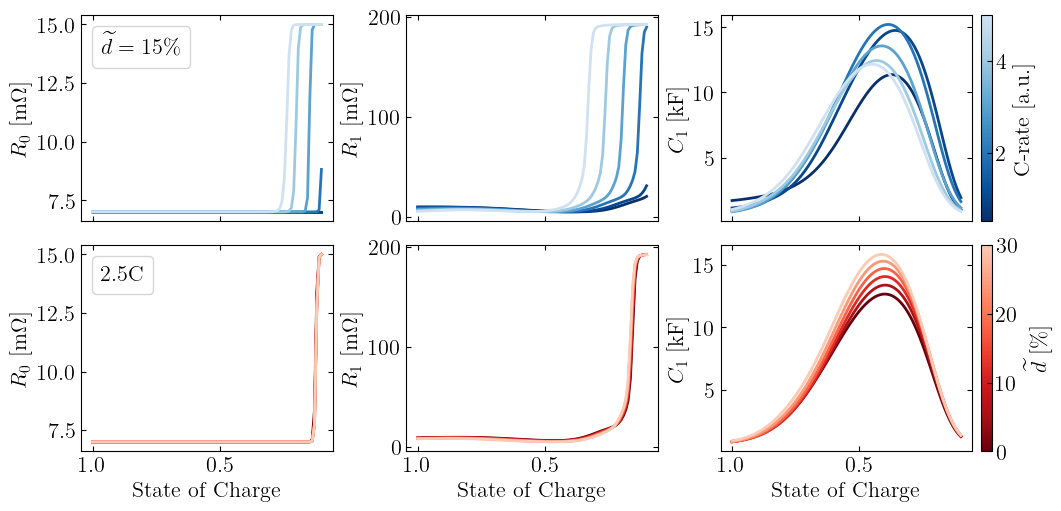

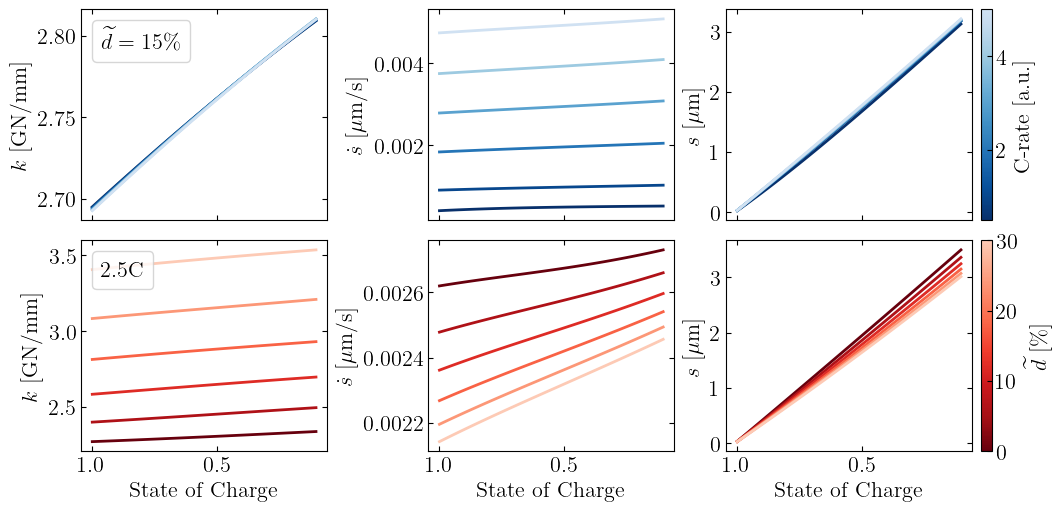

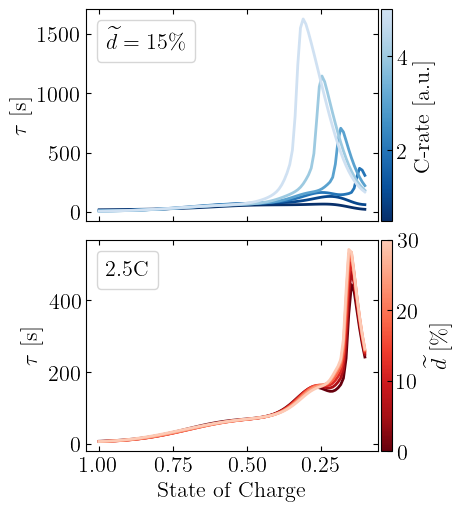

In [128]:
# ── element registry (single source of truth) ──────────────────────────
_ELEM_META = {
    'R0':   (1e3,  r'$R_0$ [m$\Omega$]'),
    'R1':   (1e3,  r'$R_1$ [m$\Omega$]'),
    'C1':   (1e-3, r'$C_1$ [kF]'),
    'tau':  (1.0,  r'$\tau$ [s]'),
    'k':    (1e2,  r'$k$ [GN/mm]'),
    'sdot': (10.0, r'$\dot{s}$ [$\mu$m/s]'),
    's':    (10.0, r'$s$ [$\mu$m]'),
}


def _compute_element(model, element, c_rate, u_per, soc_t):
    """Return y for one element along soc_t at a single (c_rate, u_per)."""
    NN = {'R0': R0_nn, 'R1': R1_nn, 'C1': C1_nn, 'k': k_nn}

    if element in NN:
        return NN[element](c_rate, u_per, soc_t)

    if element == 'tau':
        return R1_nn(c_rate, u_per, soc_t) * C1_nn(c_rate, u_per, soc_t)

    if element in ('s', 'sdot'):
        s_curr = torch.zeros((), dtype=torch.float32)
        out = []
        dsoc = float(abs(soc_t[1] - soc_t[0]))
        dt = dsoc * 3600.0 / c_rate
        for soc_val in soc_t:
            ds = sdot_nn(c_rate, u_per, soc_val, s_curr)
            ds_val = float(np.asarray(ds).squeeze())
            if element == 'sdot':
                out.append(ds_val)
            s_curr = s_curr + ds_val * dt
            if element == 's':
                out.append(s_curr.item())
        return np.asarray(out)


def _draw_sweep(ax, model, element, *, sweep, fixed, sweep_vals, soc_t, cmap_obj, norm):
    """Draw one element on `ax`. Sets ylabel + ticklabel format. No xlabel/title."""
    scale, ylabel = _ELEM_META[element]
    for val in sweep_vals:
        c_rate, u_per = (fixed, val) if sweep == 'u_per' else (val, fixed)
        y = _compute_element(model, element, c_rate, u_per, soc_t)
        ax.plot(soc_t.numpy(), y * scale, color=cmap_obj(norm(val)), lw=2)
    ax.set_ylabel(ylabel)
    ax.ticklabel_format(useOffset=False, style='plain', axis='y')
    


def _make_cmap(name):
    base = {'Blues': plt.cm.Blues_r, 'Reds': plt.cm.Reds_r}[name]
    return LinearSegmentedColormap.from_list(
        f"{name}_custom", base(np.linspace(0.0, 0.8, 256)))


def plot_element_grid(model, elements, *,
                      fixed_C=2.5, fixed_d=15.0,
                      d_sweep_vals=None, c_sweep_vals=None,
                      soc=None, figsize=None):
    """
    2  len(elements) grid.
        Top row    : fixed C = fixed_C, sweep d  (Reds  colormap, d colorbar)
        Bottom row : fixed d = fixed_d, sweep C  (Blues colormap, C colorbar)
    One colorbar per row, anchored to the right of that row.
    """
    if d_sweep_vals is None:
        d_sweep_vals = np.linspace(0, 30, 6)
    if c_sweep_vals is None:
        c_sweep_vals = np.array([0.5, 1, 2, 3, 4, 5])
    if soc is None:
        soc = np.linspace(1.0, 0.1, 100)
    soc_t = torch.as_tensor(soc, dtype=torch.float32)

    n = len(elements)
    if figsize is None:
        figsize = ((3.5 * n + 1) if n == 1 else (3.5 * n), 5)  # 3.5*n + 1 when plotting only one element

    fig, axes = plt.subplots(2, n, figsize=figsize,
                              sharex=True, constrained_layout=True)
    if n == 1:
        axes = axes.reshape(2, 1)

    cmap_red  = _make_cmap('Reds')
    cmap_blue = _make_cmap('Blues')
    norm_d = Normalize(vmin=d_sweep_vals.min(), vmax=d_sweep_vals.max())
    norm_C = Normalize(vmin=c_sweep_vals.min(), vmax=c_sweep_vals.max())

    for j, elem in enumerate(elements):
        _draw_sweep(axes[1, j], model, elem,
                    sweep='u_per', fixed=fixed_C,
                    sweep_vals=d_sweep_vals, soc_t=soc_t,
                    cmap_obj=cmap_red, norm=norm_d)
        _draw_sweep(axes[0, j], model, elem,
                    sweep='c_rate', fixed=fixed_d,
                    sweep_vals=c_sweep_vals, soc_t=soc_t,
                    cmap_obj=cmap_blue, norm=norm_C)

    # xlabels: bottom row only
    for ax in axes[1, :]:
        ax.set_xlabel('State of Charge')


    # One colorbar per row, to the right of the row's axes
    sm_d = ScalarMappable(cmap=cmap_red,  norm=norm_d); sm_d.set_array([])
    sm_C = ScalarMappable(cmap=cmap_blue, norm=norm_C); sm_C.set_array([])
    fig.colorbar(sm_d, ax=axes[1, :].tolist(), label=r'$\widetilde{d}$ [\%]', location='right', pad=0.01)
    fig.colorbar(sm_C, ax=axes[0, :].tolist(), label='C-rate [a.u.]', location='right', pad=0.01)

    axes[1, 0].legend(
                    handles=[plt.Line2D([0], [0], color='none', label=fr'${fixed_C:g}$C')],
                    loc='upper left', frameon=True, handlelength=0, handletextpad=0,)

    axes[0, 0].legend(
                    handles=[plt.Line2D([0], [0], color='none', label=fr'$\widetilde{{d}} = {fixed_d:g}\%$')], 
                    loc='upper left', frameon=True, handlelength=0, handletextpad=0,)
    
    axes[0, 0].invert_xaxis()   # propagates to all sharex'd siblings

    return fig

fig1 = plot_element_grid(BAT_MODEL, ['R0', 'R1', 'C1'], fixed_C=2.5, fixed_d=15.0)
plt.savefig(os.path.join('element_figs',f'grid_R0_R1_C1_{model_name}.pdf'), bbox_inches='tight')
plt.show()

fig2 = plot_element_grid(BAT_MODEL, ['k', 'sdot', 's'], fixed_C=2.5, fixed_d=15.0)
plt.savefig(os.path.join('element_figs', f'grid_k_sdot_s_{model_name}.pdf'), bbox_inches='tight')
plt.show()

fig3 = plot_element_grid(BAT_MODEL, ['tau'], fixed_C=2.5, fixed_d=15.0)
plt.savefig(os.path.join('element_figs',f'grid_tau_{model_name}.pdf'), bbox_inches='tight')
plt.show()

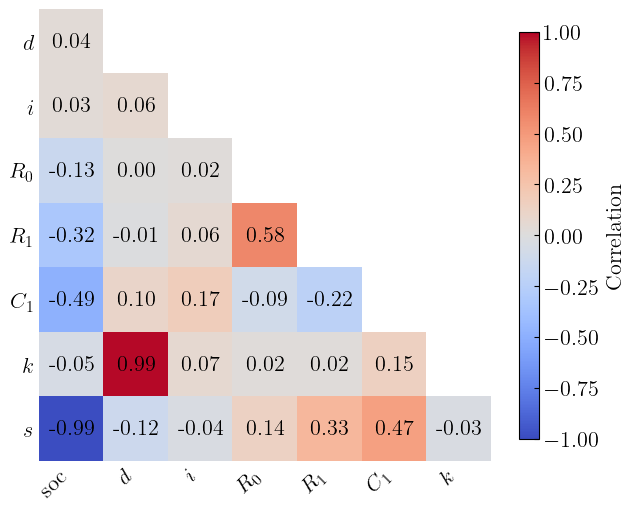

In [88]:
# X = data[['soc','u','I','R0','R1','C1','k','s']].values
# feature_names = ['soc','u','I','R0','R1','C1','k','s']
# with np.errstate(invalid="ignore", divide="ignore"):
#     corr = np.corrcoef(X, rowvar=False)


# fig, ax_corr = plt.subplots(figsize=(7, 5))
# im = ax_corr.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# ax_corr.set_xticks(np.arange(len(feature_names)))
# ax_corr.set_yticks(np.arange(len(feature_names)))
# ax_corr.set_xticklabels(feature_names, rotation=45, ha="right")
# ax_corr.set_yticklabels(feature_names)
# ax_corr.set_title("Correlation matrix")

# for i in range(corr.shape[0]):
#     for j in range(corr.shape[1]):
#         ax_corr.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", color="black")

# fig.colorbar(im, ax=ax_corr, label="Correlation")
# plt.tight_layout()
# plt.show()

X = data[['soc','u_per','C','R0','R1','C1','k','s']].values
feature_names = ['soc', r'$d$', r'$i$', r'$R_0$', r'$R_1$', r'$C_1$', r'$k$', r'$s$']

with np.errstate(invalid="ignore", divide="ignore"):
    corr = np.corrcoef(X, rowvar=False)

# Keep strictly lower triangle (no diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool), k=0)
corr_masked = np.where(mask, np.nan, corr)

# Drop the now-empty first column and last row
corr_trim = corr_masked[1:, :-1]
row_labels = feature_names[1:]
col_labels = feature_names[:-1]

cmap = plt.cm.coolwarm.copy()
cmap.set_bad(color="white")

fig, ax_corr = plt.subplots(figsize=(7, 5), constrained_layout=True)
im = ax_corr.imshow(corr_trim, cmap=cmap, vmin=-1, vmax=1)

ax_corr.set_xticks(np.arange(len(col_labels)))
ax_corr.set_yticks(np.arange(len(row_labels)))
ax_corr.set_xticklabels(col_labels, rotation=45, ha="right")
ax_corr.set_yticklabels(row_labels)
# ax_corr.set_title("Correlation matrix")

for i in range(corr_trim.shape[0]):
    for j in range(corr_trim.shape[1]):
        if not np.isnan(corr_trim[i, j]):
            ax_corr.text(j, i, f"{corr_trim[i, j]:.2f}",
                         ha="center", va="center", color="black")

# Kill the spines
for s in ax_corr.spines.values():
    s.set_visible(False)
ax_corr.tick_params(length=0)  # also remove tick marks

fig.colorbar(im, ax=ax_corr, label="Correlation", shrink=0.9)
#plt.savefig(f'element_corr_matrix.pdf')

In [55]:
df_CC = Param_symbol.read_raw_data('merged_DC_hyper')
df_CC = Param_symbol.read_raw_data('merged_pulse_hyper')
display(df_CC)

,u_par,C,t,V,F,u,Ue,soc,I,trajectory,eta
0,19.1,4.5,0,4.229418,0.078557,-2.745291,4.324996,0.999999,11.200985,0,0.095578
1,19.1,4.5,1,4.118165,0.078575,-2.745291,4.321218,0.998758,22.401970,0,0.203053
2,19.1,4.5,2,4.099471,0.078591,-2.745291,4.317412,0.997508,22.401970,0,0.217940
3,19.1,4.5,3,4.084324,0.078608,-2.745291,4.313605,0.996258,22.401970,0,0.229282
4,19.1,4.5,4,4.071481,0.078625,-2.745291,4.309799,0.995008,22.401970,0,0.238318
...,...,...,...,...,...,...,...,...,...,...,...
227346,17.2,2.5,2723,2.619369,0.080803,-2.472199,3.381726,0.096906,12.445539,74,0.762358
227347,17.2,2.5,2724,2.579749,0.080813,-2.472199,3.379533,0.096211,12.445539,74,0.799784
227348,17.2,2.5,2725,2.532106,0.080822,-2.472199,3.377339,0.095517,12.445539,74,0.845233
227349,17.2,2.5,2726,2.478750,0.080832,-2.472199,3.375146,0.094822,12.445539,74,0.896395


In [94]:
# Extract expressions from symbolic regression results
def extract_expressions(run_id):
    # Load the symbolic regression results
    elements = ['k', 'R1', 'C1', 'R0']#, 's']
    
    expressions = {}

    for elem in elements:
    
        results_path = Path(f'sr_models/model_{elem}_{run_id}.csv')
        if not results_path.exists():
            raise FileNotFoundError(f"Results file not found: {results_path}")
    
        results_df = pd.read_csv(results_path)

        expr = results_df['sympy_format']# == int(results_df['complexity'].mean())]
        expressions[elem] = expr

    
    return expressions

print(f"Loading symbolic regression results for RUN_ID: {RUN_ID}")
#res, R0_expr, R1_expr, C1_expr, k_expr, s_expr = extract_expressions(RUN_ID)
expressions = extract_expressions(RUN_ID)
R0_expr = expressions['R0']
R1_expr = expressions['R1']
C1_expr = expressions['C1']
k_expr = expressions['k']
# s_expr = expressions['s']

latent_variables = {'x0': 'c-rate', 'x1': 'd_per', 'x2': 'soc', 'x3':'s'}


from collections import Counter

symbol_counts = {}
for elem in VARIABLES:
    counter = Counter()
    for expr in expressions[elem]:
        sympy_expr = sp.sympify(expr)

        counter.update(map(str, sympy_expr.free_symbols))

    symbol_counts[elem] = counter

# convert to dataframe for better visualization
symbol_counts_df = pd.DataFrame(symbol_counts).fillna(0).astype(int)

for elem in symbol_counts_df:
    symbol_counts_df[elem] = 100 * symbol_counts_df[elem] / expressions[elem].shape[0]

df_symcounts = symbol_counts_df.transpose()
display(df_symcounts)
print(f'Latent variables: {latent_variables}')
df_symcounts.columns = [latent_variables.get(col, col) for col in df_symcounts.columns]
display(df_symcounts)

# round values to 1 decimal place
df_symcounts = df_symcounts.round(1)

def df_latex_table(df, caption=None, label=None):
    latex_str = df.to_latex(index=True, escape=False)
    if caption:
        latex_str = latex_str.replace('\\begin{tabular}', f'\\begin{{table}}[ht]\n\\centering\n\\caption{{{caption}}}\n\\begin{{tabular}}')
    if label:
        latex_str = latex_str.replace('\\end{tabular}', f'\\end{{tabular}}\n\\label{{{label}}}\n\\end{{table}}')
    return latex_str

latex_table = df_latex_table(df_symcounts, caption="Symbol usage percentages in SR expressions", label="tab:symbol_usage")
print(latex_table)


Loading symbolic regression results for RUN_ID: 1405_Jesper


,soc,C,d
R0,95.833333,83.333333,12.500000
R1,96.153846,84.615385,11.538462
C1,96.000000,68.000000,56.000000
k,76.190476,0.000000,95.238095


Latent variables: {'x0': 'c-rate', 'x1': 'd_per', 'x2': 'soc', 'x3': 's'}


,soc,C,d
R0,95.833333,83.333333,12.500000
R1,96.153846,84.615385,11.538462
C1,96.000000,68.000000,56.000000
k,76.190476,0.000000,95.238095


\begin{table}[ht]
\centering
\caption{Symbol usage percentages in SR expressions}
\begin{tabular}{lrrr}
\toprule
 & soc & C & d \\
\midrule
R0 & 95.800000 & 83.300000 & 12.500000 \\
R1 & 96.200000 & 84.600000 & 11.500000 \\
C1 & 96.000000 & 68.000000 & 56.000000 \\
k & 76.200000 & 0.000000 & 95.200000 \\
\bottomrule
\end{tabular}
\label{tab:symbol_usage}
\end{table}



In [131]:
def display_expresions(elem, latent_variables, expressions = expressions, complexity = None, ref_values = REF_VALUES):

    print(f"\nExpression for {elem}:")
    for j,expr in enumerate(expressions[elem]):
        sympy_expr = sp.sympify(expr)
        if complexity is not None:
            display(Math(f"\\Large {complexity[j]}, idx: {j}: {elem} = {sp.latex(ref_values[elem] * sympy_expr)}"))
        else:
            display(Math(f"\\Large {j}: {elem} = {sp.latex(sympy_expr)}"))

sr_models/model_C1_final.csv


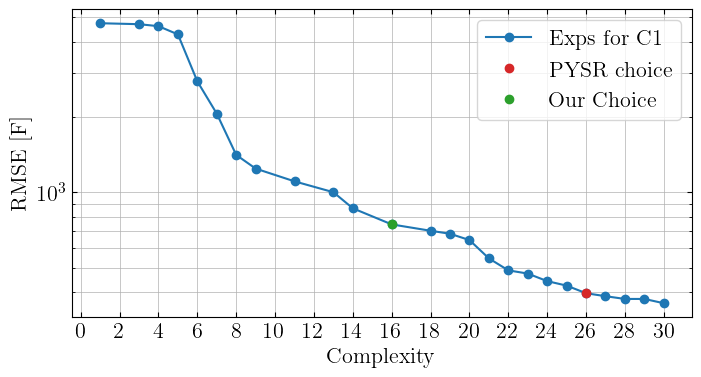


Expression for C1:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [142]:
RUN_ID = 'final'
elem = 'C1'
#Param_symbol.post_pareto_plot(elem,run_id=RUN_ID)
df = pd.read_csv(f'sr_models/model_{elem}_{RUN_ID}.csv')

complexity = df['complexity'].values


def post_pareto_plot(elem, run_id, colors = COLORS, diff = 1, ref_values = REF_VALUES):
    print(f'sr_models/model_{elem}_{run_id}.csv')
    df_model = pd.read_csv(f'sr_models/model_{elem}_{run_id}.csv')
    best = pd.read_csv(f'sr_models/model_{elem}_best_{run_id}.csv')
    best_complexity = float(best.iloc[0, 0])
    best_rows = df_model[np.isclose(df_model['complexity'], best_complexity)]
    best_ind = int(best.iloc[0,0])
    plt.figure(figsize=(8, 4))
    plt.xticks(np.arange(0, df_model['complexity'].max() + 1, 2))
    plt.grid(True, which="both", ls="-", linewidth=0.5)
    plt.plot(df_model['complexity'], np.sqrt(df_model['loss']) * ref_values[elem], marker='o', linestyle='-', color=colors[0], label=f'Exps for {elem}')
    plt.plot(best_rows['complexity'], np.sqrt(best_rows['loss']) * ref_values[elem], marker='o', linestyle='', color=colors[1], label='PYSR choice')
    plt.plot(16, np.sqrt(df_model.iloc[11]['loss']) * ref_values[elem], marker='o', linestyle='', color=colors[2], label='Our Choice')
    plt.xlabel('Complexity')
    plt.ylabel('RMSE [F]')
    plt.yscale('log')
    plt.legend()
    plt.show()


post_pareto_plot(elem, RUN_ID)

display_expresions(elem, latent_variables, complexity= complexity)


#best_SR = {'R0': , 'R1': , 'C1': 15, 'k': , 's': }

In [158]:
chosen_SR = {
    'R0': 8, # JN
    'R1': 8, # JN
    'C1': 11, # JN
    'k': 7,
    # 's': 11
}

best_SR = {
    'R0': 23, # JN
    'R1':18, # JN,
    'C1': 20, # JN
    'k': 18, # JN
    # 's': 11 # JH
}

C1_expr = expressions['C1'][best_SR['C1']]
R0_expr = expressions['R0'][best_SR['R0']]
R1_expr = expressions['R1'][best_SR['R1']]
k_expr = expressions['k'][best_SR['k']]
# s_expr = expressions['s'][best_SR['s']]

R0_func = sp.lambdify(('C', 'd', 'soc'), R0_expr, 'numpy')
k_func = sp.lambdify(('C', 'd', 'soc'), k_expr, 'numpy')
R1_func = sp.lambdify(('C', 'd', 'soc'), R1_expr, 'numpy')
C1_func = sp.lambdify(('C', 'd', 'soc'), C1_expr, 'numpy')
# s_func = sp.lambdify(('C', 'd', 'soc','x3'), s_expr, 'numpy')

print(f's = {sp.latex(C1_expr)}')


s = \mathtt{\text{(0.1518522*soc*(d + exp(C)))**C*(soc + sqrt(C - 0.05199786)/(soc**soc)**11.151432)}}


In [ ]:
# Normalization the SR fits expect at their inputs.
# Update these if you retrain SR with a different feature range.
SR_C_NORM = 5.0     # c_rate trained on c_rate / 5
SR_D_NORM = 30.0    # u_per  trained on u_per  / 30


def _compute_element(element, c_rate, u_per, soc_t, source='nn'):
    """source ∈ {'nn','sr'}. s/sdot always use sdot_nn (no SR variant yet)."""
    # SR functions were trained on normalized inputs; NN handles its own norm.
    if source == 'sr':
        c_arg, u_arg = c_rate / SR_C_NORM, u_per / SR_D_NORM
        funcs = {'R0': R0_func, 'R1': R1_func, 'C1': C1_func, 'k': k_func}
    elif source == 'nn':
        c_arg, u_arg = c_rate, u_per
        funcs = {'R0': R0_nn, 'R1': R1_nn, 'C1': C1_nn, 'k': k_nn}
    else:
        raise ValueError(f"source must be 'nn' or 'sr', got {source!r}")

    if element in funcs:
        return funcs[element](c_arg, u_arg, soc_t)

    if element == 'tau':
        return (funcs['R1'](c_arg, u_arg, soc_t) * funcs['C1'](c_arg, u_arg, soc_t))

    if element in ('s', 'sdot'):
        # NN-only path — uses raw c_rate/u_per via sdot_nn → sdot_predict.
        s_curr = torch.zeros((), dtype=torch.float32)
        out = []
        dsoc = float(abs(soc_t[1] - soc_t[0]))
        dt = dsoc * 3600.0 / c_rate
        for soc_val in soc_t:
            ds = sdot_nn(c_rate, u_per, soc_val, s_curr)
            ds_val = float(np.asarray(ds).squeeze())
            if element == 'sdot':
                out.append(ds_val)
            s_curr = s_curr + ds_val * dt
            if element == 's':
                out.append(s_curr.item())
        return np.asarray(out)

    raise ValueError(f"unknown element {element!r}")


# ── per-axis draw, possibly two sources overlaid ────────────────────────
_LINESTYLE = {'nn': '--', 'sr': '-'}   # NN striped, SR solid

def _draw_sweep(ax, element, *, sweep, fixed, sweep_vals, soc_t,
                cmap_obj, norm, models='nn'):
    """models in {'nn','sr','both'}.  When 'both', NN is dashed, SR is solid."""
    scale_nn, ylabel = _ELEM_META[element]
    scale_sr = REF_VALUES[element]

    # s/sdot has only an NN implementation — never draw two lines for it
    if element in ('s', 'sdot'):
        sources = ['nn']
    elif models == 'both':
        sources = ['nn', 'sr']
    elif models in ('nn', 'sr'):
        sources = [models]
    else:
        raise ValueError(f"models must be 'nn'/'sr'/'both', got {models!r}")

    # If only one source, use solid regardless of which it is
    styles = _LINESTYLE if len(sources) == 2 else {sources[0]: '-'}

    for val in sweep_vals:
        c_rate, u_per = (fixed, val) if sweep == 'u_per' else (val, fixed)
        color = cmap_obj(norm(val))
        for src in sources:
            y = _compute_element(element, c_rate, u_per, soc_t, source=src)
            if src == 'nn':
                y_disp = y * scale_nn
            elif src == 'sr':
                y_disp = y * scale_sr * scale_nn

            ax.plot(soc_t.numpy(), y_disp, color=color, lw=2, linestyle=styles[src])

    ax.set_ylabel(ylabel)
    ax.ticklabel_format(useOffset=False, style='plain', axis='y')


# ── grid orchestrator ───────────────────────────────────────────────────
def plot_element_grid(elements, *, models='nn',
                      fixed_C=2.5, fixed_d=15.0,
                      d_sweep_vals=None, c_sweep_vals=None,
                      soc=None, figsize=None):
    """
    2  len(elements) grid.
        Top row    : fixed d, sweep C  (Blues, C-rate colorbar)
        Bottom row : fixed C, sweep d  (Reds,  d colorbar)
    models : 'nn' | 'sr' | 'both'.  When 'both', NN is dashed and SR is solid.
    """
    if models not in ('nn', 'sr', 'both'):
        raise ValueError(f"models must be 'nn'/'sr'/'both', got {models!r}")

    if d_sweep_vals is None:
        d_sweep_vals = np.linspace(0, 30, 6)
    if c_sweep_vals is None:
        c_sweep_vals = np.array([0.5, 1, 2, 3, 4, 5])
        # c_sweep_vals = np.linspace(0.0, 5.0, 6)
    if soc is None:
        soc = np.linspace(1.0, 0.1, 100)
    soc_t = torch.as_tensor(soc, dtype=torch.float32)

    n = len(elements)
    if figsize is None:
        figsize = ((3.5 * n + 1) if n == 1 else (3.5 * n), 5)

    fig, axes = plt.subplots(2, n, figsize=figsize,
                              sharex=True, constrained_layout=True)
    if n == 1:
        axes = axes.reshape(2, 1)

    cmap_red, cmap_blue = _make_cmap('Reds'), _make_cmap('Blues')
    norm_d = Normalize(vmin=d_sweep_vals.min(), vmax=d_sweep_vals.max())
    norm_C = Normalize(vmin=c_sweep_vals.min(), vmax=c_sweep_vals.max())

    for j, elem in enumerate(elements):
        _draw_sweep(axes[1, j], elem, sweep='u_per', fixed=fixed_C,
                    sweep_vals=d_sweep_vals, soc_t=soc_t,
                    cmap_obj=cmap_red, norm=norm_d, models=models)
        _draw_sweep(axes[0, j], elem, sweep='c_rate', fixed=fixed_d,
                    sweep_vals=c_sweep_vals, soc_t=soc_t,
                    cmap_obj=cmap_blue, norm=norm_C, models=models)

    for ax in axes[1, :]:
        ax.set_xlabel('State of Charge')

    sm_d = ScalarMappable(cmap=cmap_red,  norm=norm_d); sm_d.set_array([])
    sm_C = ScalarMappable(cmap=cmap_blue, norm=norm_C); sm_C.set_array([])
    fig.colorbar(sm_d, ax=axes[1, :].tolist(),
                 label=r'$\widetilde{d}$ [\%]', location='right', pad=0.01)
    fig.colorbar(sm_C, ax=axes[0, :].tolist(),
                 label='C-rate [a.u.]', location='right', pad=0.01)

    # Fixed-value tags
    axes[1, 0].legend(
        handles=[plt.Line2D([0], [0], color='none', label=fr'${fixed_C:g}$C')], loc='upper left', frameon=True, handlelength=0, handletextpad=0)
    axes[0, 0].legend(
        handles=[plt.Line2D([0], [0], color='none', label=fr'$\widetilde{{d}} = {fixed_d:g}\%$')],
        loc='upper left', frameon=True, handlelength=0, handletextpad=0)

    # Linestyle key — only when both sources are overlaid
    if models == 'both':
        axes[0, -1].legend(
            handles=[
                plt.Line2D([0], [0], color='gray', linestyle='--', lw=2, label='NN'),
                plt.Line2D([0], [0], color='gray', linestyle='-',  lw=2, label='SR'),
            ],
            loc='upper left', frameon=True)

    axes[0, 0].invert_xaxis()
    return fig

<lambdifygenerated-48>:2: RuntimeWarning: invalid value encountered in sqrt
  return (0.1518522*soc*(d + exp(C)))**C*(soc + sqrt(C - 0.05199786)/(soc**soc)**11.151432)


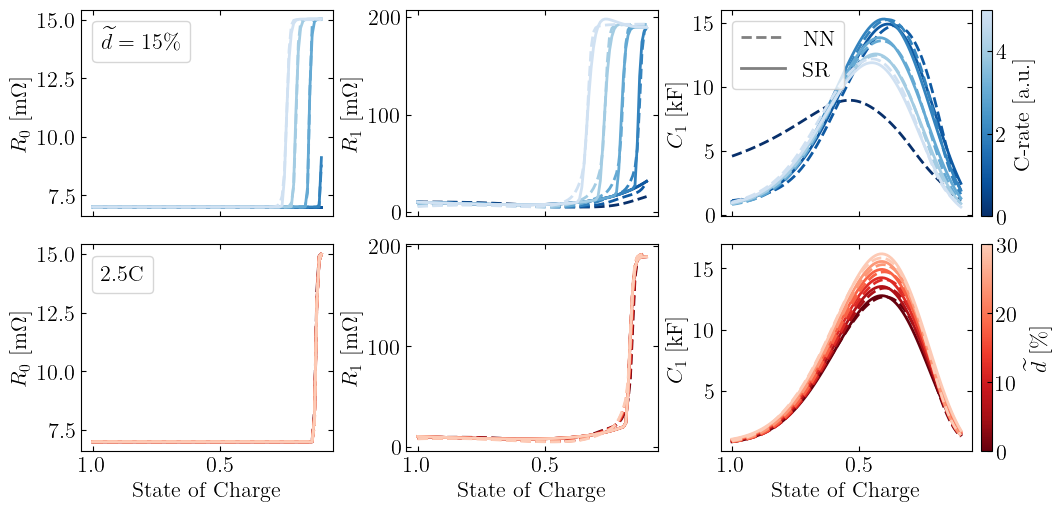

In [171]:
# # NN only — solid lines
# plot_element_grid(['R0', 'R1', 'C1', 'tau'], models='nn',
#                   fixed_C=2.5, fixed_d=15.0)
# plt.savefig(os.path.join('element_figs', f'grid_nn_{model_name}.pdf'),
#             bbox_inches='tight')
# plt.show()

# # SR only — solid lines
# plot_element_grid(['R0', 'R1', 'C1', 'tau'], models='sr',
#                   fixed_C=2.5, fixed_d=15.0)
# plt.savefig(os.path.join('element_figs', f'grid_sr_{model_name}.pdf'),
#             bbox_inches='tight')
# plt.show()


plot_element_grid(['R0', 'R1', 'C1'], models='both',
                  fixed_C=2.5, fixed_d=15.0)
plt.savefig(os.path.join('element_figs', f'grid_both_{model_name}.pdf'),
            bbox_inches='tight')
plt.show()